# Protein Interaction dataset(minimized) with dask_cudf

## Import cuxfilter

In [1]:
from dask.distributed import Client, wait
from dask_cuda import LocalCUDACluster

client = Client(LocalCUDACluster())

2022-04-19 15:16:57,452 - distributed.preloading - INFO - Import preload module: dask_cuda.initialize
2022-04-19 15:16:57,507 - distributed.preloading - INFO - Import preload module: dask_cuda.initialize


In [22]:
client

Connection method: Cluster object,Cluster type: dask_cuda.LocalCUDACluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 31.26 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46651,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 2
Started: 18 hours ago,Total memory: 31.26 GiB
Comm: tcp://127.0.0.1:36899,Total threads: 1
Dashboard: http://127.0.0.1:36321/status,Memory: 15.63 GiB
Nanny: tcp://127.0.0.1:46077,


In [16]:
def datasize(num1, num2):
    return ('{0:.2f} GB'.format(num1 / float(1024 ** 3)), '{0:.2f} GB'.format(num2/ float(1024 ** 3)))

In [19]:
[datasize(ws['options']['data'][1]['memory_limit'], ws['options']['data'][1]['device_memory_limit']) for ws in client.cluster.worker_spec.values()]

[('15.63 GB', '19.20 GB'), ('15.63 GB', '19.20 GB')]

In [ ]:
import cuxfilter
import dask_cudf
import cugraph
import numpy as np, pandas as pd

ITERATIONS=500
THETA=1.0
OPTIMIZE=True

## Load required datasets using dask_cudf

In [ ]:
edges = dask_cudf.read_csv('./data/edges.csv', usecols=['Source','Destination', 'edgeColor'])
nodes = dask_cudf.read_csv('./data/nodes.csv', usecols=['x', 'y', 'SYMBOL', 'Color'])
nodes.Color = nodes.Color - nodes.Color.min()

In [25]:
nodes

,x,y,SYMBOL,Color
npartitions=1,,,,
,float64,float64,int64,int64
,...,...,...,...


In [26]:
edges

,source,destination,color
npartitions=1,,,
,int64,int64,int64
,...,...,...


## preprocess the data

In [ ]:
edges.columns=["source", "destination", 'color']

G = cugraph.Graph()
G.from_cudf_edgelist(edges)

nodes_ = dask_cudf.from_cudf(cugraph.layout.force_atlas2(G, max_iter=500,
                strong_gravity_mode=False,
                outbound_attraction_distribution=True,
                lin_log_mode=False,
                barnes_hut_optimize=OPTIMIZE, barnes_hut_theta=THETA, verbose=True), npartitions=2)

In [ ]:
nodes_1 = nodes_.merge(nodes, left_on='vertex', right_on='SYMBOL', suffixes=('', '_y'))[list(nodes.columns)]

In [28]:
nodes_1

,x,y,SYMBOL,Color
npartitions=2,,,,
,float32,float32,int64,int64
,...,...,...,...
,...,...,...,...


## Define charts

Using `dask_cudf.DataFrame.persist()` before passing it to cuxfilter.DataFrame turns a lazy Dask collection into a Dask collection with the same metadata, but now with the results fully computed or actively computing in the background. 

Passing a `dask_cudf.DataFrame` without `persist()` is also supported.

In [ ]:
cux_df = cuxfilter.DataFrame.load_graph((nodes_1.persist(), edges.persist()))

In [ ]:
chart0 = cuxfilter.charts.graph(edge_target='destination',edge_color_palette=['gray', 'black'], 
                                            node_id='SYMBOL', timeout=200, edge_aggregate_col='color',
                                            node_aggregate_col='Color', node_aggregate_fn='mean', node_pixel_shade_type='linear',
                                            edge_render_type='direct',#other option available -> 'curved'
                                            edge_transparency=0.5, edge_color_palett=["black", "gray", "pink"]
                                          )

chart1 = cuxfilter.charts.bar(x='Color', data_points=10)

## Create a dashboard object

In [ ]:
d = cux_df.dashboard([chart0, chart1], layout=cuxfilter.layouts.double_feature)

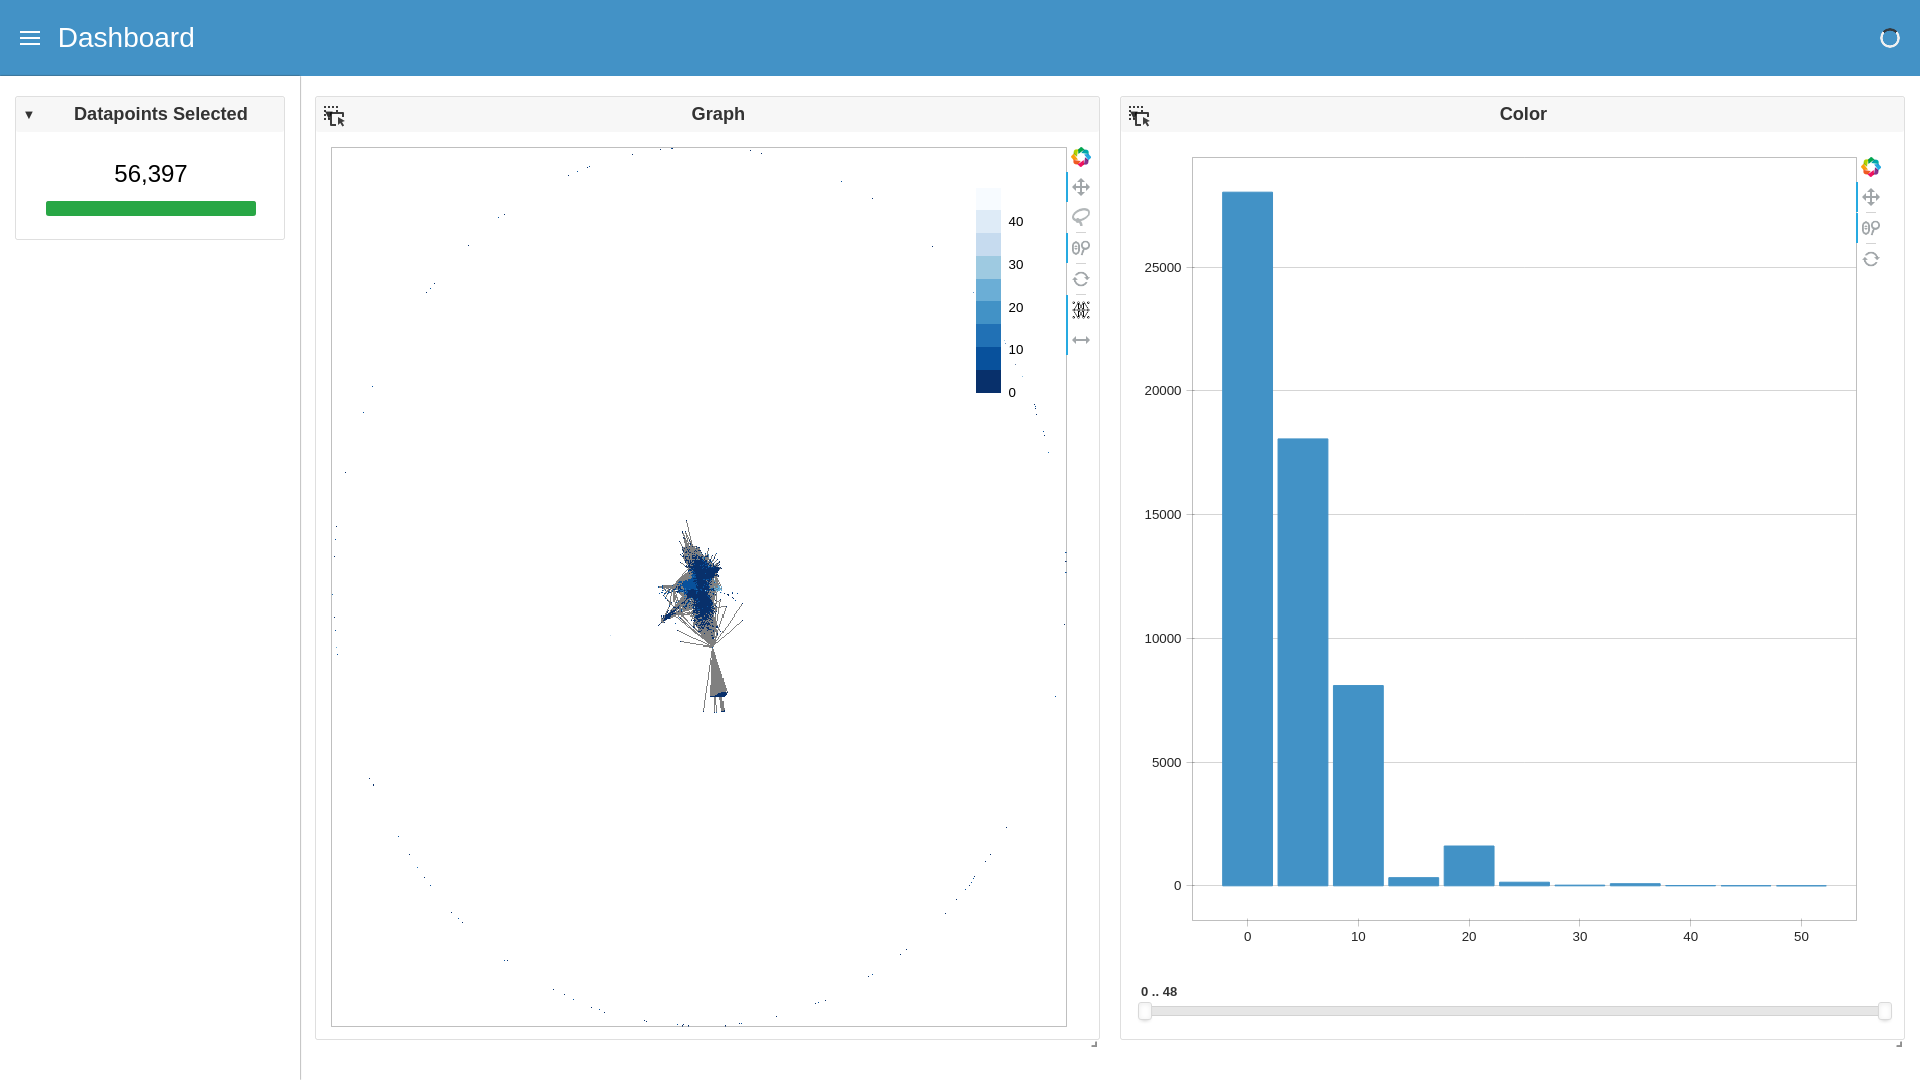

In [31]:
#execute below line for dashboard preview
# await d.preview()

## Starting the dashboard

1. d.show('current_notebook_url:current_notebook_port') remote dashboard

2. d.app() inline within the notebook cell

Incase you need to stop the server:

- d.stop()

In [ ]:
# d.show() # notebook_url="http://localhost:8888"
# d.app() # run the dashboard within the notebook cell

## Export the queried data into a dataframe

In [ ]:
queried_df = d.export()